In [1]:
from tqdm import tqdm
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


чтобы результаты (разбиение train/val, инициализация весов) были повторяемыми:

In [2]:
def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

преобразуем в Tensor, нормализуем по mean/std CIFAR10:

In [3]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)
print("One sample shape:", train_dataset[0][0].shape)

100%|██████████| 170M/170M [00:20<00:00, 8.50MB/s]


One sample shape: torch.Size([3, 32, 32])


проверка DataLoader:

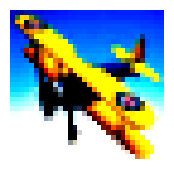

In [4]:
train_loader_small = DataLoader(train_dataset, batch_size=8, shuffle=True)
batch = next(iter(train_loader_small))

img = batch[0][1].permute(1, 2, 0).numpy()
plt.figure(figsize=(2,2))
plt.imshow(img)
plt.axis("off")
plt.show()

создаем простую CNN с 3 свёртками + pooling, это будет baseline, с которым сравним ResNet18

In [5]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 32->16
        x = self.pool(F.relu(self.conv2(x)))  # 16->8
        x = self.pool(F.relu(self.conv3(x)))  # 8->4
        x = x.view(x.size(0), -1)             # (B, 64*4*4)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# sanity-check
cnn = BasicCNN()
out = cnn(batch[0])
print("BasicCNN output:", out.shape)  # (8, 10)


BasicCNN output: torch.Size([8, 10])


меняем ResNet под задачу: self.conv1 перезаписыввем, добавиляем conv2, вместо None теперь возвращаем out

In [6]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)
        return out


собираем стадии (layer1..layer4), каждая из которых содержит 2 residual блока (как в ResNet18), добавляем AdaptiveAvgPool2d(1,1) и Linear(512 -> 10)

выставляем cifar_stem=True, так как для CIFAR10 (32×32) классический 7x7 stride=2 + maxpool слишком быстро уменьшает размер карты признаков, а CIFAR-stem (3×3 stride=1 без maxpool) обычно учится лучше

In [7]:
class ResNet18(nn.Module):
    def __init__(self, num_classes=10, cifar_stem=True):
        super().__init__()
        self.in_channels = 64
        self.relu = nn.ReLU(inplace=True)

        if cifar_stem:
            self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
            self.bn1 = nn.BatchNorm2d(64)
            self.maxpool = nn.Identity()
        else:
            self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
            self.bn1 = nn.BatchNorm2d(64)
            self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self.make_layer(64,  blocks=2, stride=1)
        self.layer2 = self.make_layer(128, blocks=2, stride=2)
        self.layer3 = self.make_layer(256, blocks=2, stride=2)
        self.layer4 = self.make_layer(512, blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = [ResNetBlock(self.in_channels, out_channels, stride=stride, downsample=downsample)]
        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(ResNetBlock(self.in_channels, out_channels, stride=1))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)          # (B, 512, 1, 1)
        x = torch.flatten(x, 1)      # (B, 512)
        x = self.fc(x)               # (B, 10)
        return x

# sanity-check
resnet = ResNet18()
out = resnet(batch[0])
print("ResNet18 output:", out.shape)  # (8, 10)

ResNet18 output: torch.Size([8, 10])


выносим одинаковую логику для валидации и теста: loss + accuracy без градиентов

In [13]:
@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)

        total_loss += loss.item()
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), 100.0 * correct / total

делаем Trainer, который принимает model_ctor (функция/класс, создающая модель), сохраняем train/val loss и train/val accuracy, после обучения считаем test loss/acc

In [8]:
class Trainer:
    def __init__(self, config, model_ctor, transform=None):
        self.config = config
        self.transform = transform
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.model = model_ctor().to(self.device)

        opt_name = self.config.get("optimizer", "adam").lower()
        lr = self.config["lr"]
        wd = self.config.get("weight_decay", 0.0)

        if opt_name == "sgd":
            self.optimizer = SGD(
                self.model.parameters(),
                lr=lr,
                momentum=self.config.get("momentum", 0.9),
                weight_decay=wd
            )
        else:
            self.optimizer = Adam(self.model.parameters(), lr=lr, weight_decay=wd)

        self.scheduler = StepLR(
            self.optimizer,
            step_size=self.config.get("step_size", 5),
            gamma=self.config.get("gamma", 0.1)
        )
        self.loss_fn = nn.CrossEntropyLoss()

        self.setup_dataloaders()

        self.history = {"train_loss": [], "train_acc": [],
                        "val_loss": [], "val_acc": []}

    def setup_dataloaders(self):
        train_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_ds = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_idx, val_idx = train_test_split(
            list(range(len(train_full))),
            test_size=self.config["test_size"],
            random_state=42,
            shuffle=True
        )
        train_ds = Subset(train_full, train_idx)
        val_ds = Subset(train_full, val_idx)

        num_workers = self.config.get("num_workers", 2)
        pin_memory = (self.device == "cuda")

        self.train_loader = DataLoader(train_ds, batch_size=self.config["batch_size"],
                                       shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
        self.val_loader = DataLoader(val_ds, batch_size=self.config["batch_size"],
                                     shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
        self.test_loader = DataLoader(test_ds, batch_size=self.config["batch_size"],
                                      shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

    def train_one_epoch(self):
        self.model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for x, y in tqdm(self.train_loader, leave=False):
            x, y = x.to(self.device), y.to(self.device)

            self.optimizer.zero_grad(set_to_none=True)
            logits = self.model(x)
            loss = self.loss_fn(logits, y)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

        return total_loss / len(self.train_loader), 100.0 * correct / total

    def run(self):
        for epoch in range(self.config["num_epochs"]):
            tr_loss, tr_acc = self.train_one_epoch()
            val_loss, val_acc = evaluate(self.model, self.val_loader, self.loss_fn, self.device)
            self.scheduler.step()

            self.history["train_loss"].append(tr_loss)
            self.history["train_acc"].append(tr_acc)
            self.history["val_loss"].append(val_loss)
            self.history["val_acc"].append(val_acc)

            print(f"Epoch {epoch+1}/{self.config['num_epochs']} | "
                  f"train loss={tr_loss:.4f}, acc={tr_acc:.2f}% | "
                  f"val loss={val_loss:.4f}, acc={val_acc:.2f}%")

        test_loss, test_acc = evaluate(self.model, self.test_loader, self.loss_fn, self.device)
        print(f"TEST | loss={test_loss:.4f}, acc={test_acc:.2f}%")
        return test_loss, test_acc

рисуем графики loss и accuracy для двух моделей (train/val)

In [9]:
def plot_compare(hist_a, hist_b, name_a="BasicCNN", name_b="ResNet18"):
    epochs = range(1, len(hist_a["train_loss"]) + 1)

    plt.figure(figsize=(14, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist_a["train_loss"], label=f"{name_a} train")
    plt.plot(epochs, hist_a["val_loss"], label=f"{name_a} val")
    plt.plot(epochs, hist_b["train_loss"], label=f"{name_b} train")
    plt.plot(epochs, hist_b["val_loss"], label=f"{name_b} val")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist_a["train_acc"], label=f"{name_a} train")
    plt.plot(epochs, hist_a["val_acc"], label=f"{name_a} val")
    plt.plot(epochs, hist_b["train_acc"], label=f"{name_b} train")
    plt.plot(epochs, hist_b["val_acc"], label=f"{name_b} val")
    plt.title("Accuracy (%)")
    plt.xlabel("Epoch")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

для Adam пишут, что чаще всего адекватнее lr=1e-3, поэтому не стала ставить 0.01

In [11]:
config = {
    "num_epochs": 10,
    "lr": 1e-3,
    "batch_size": 128,
    "test_size": 0.2,
    "optimizer": "adam",
    "step_size": 5,
    "gamma": 0.1,
    "num_workers": 2,
    "weight_decay": 0.0
}

обучаем BasicCNN

In [ ]:
trainer_cnn = Trainer(config, model_ctor=BasicCNN, transform=transform)
cnn_test_loss, cnn_test_acc = trainer_cnn.run()

Epoch 1/10 | train loss=1.5804, acc=42.53% | val loss=1.3209, acc=52.17%


Epoch 2/10 | train loss=1.2303, acc=56.06% | val loss=1.1153, acc=60.84%


Epoch 3/10 | train loss=1.0527, acc=62.86% | val loss=1.0536, acc=62.98%


Epoch 4/10 | train loss=0.9454, acc=66.67% | val loss=0.9507, acc=66.68%


Epoch 5/10 | train loss=0.8574, acc=70.00% | val loss=0.8971, acc=68.93%


Epoch 6/10 | train loss=0.7281, acc=74.73% | val loss=0.8492, acc=70.69%


Epoch 7/10 | train loss=0.7050, acc=75.49% | val loss=0.8453, acc=70.80%


обучаем ResNet18

In [ ]:
trainer_resnet = Trainer(
    config,
    model_ctor=lambda: ResNet18(num_classes=10, cifar_stem=True),
    transform=transform
)
res_test_loss, res_test_acc = trainer_resnet.run()


Epoch 1/10 | train loss=1.4011, acc=48.76% | val loss=1.1910, acc=56.22%


Графики сравнения и выводы по ним:

In [ ]:
plot_compare(trainer_cnn.history, trainer_resnet.history, name_a="BasicCNN", name_b="ResNet18")

print("CNN test:", cnn_test_loss, cnn_test_acc)
print("ResNet test:", res_test_loss, res_test_acc)